In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import pickle

2. CARREGAMENTO DO DATASET


In [ ]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/klaytoncastro/idp-machinelearning/main/datasets/AirQualityUCI.csv",
    sep=';',
    decimal=','
)

df = df.dropna(axis=1, how='all')

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [ ]:
# Substituir valores inválidos
df.replace(-200, np.nan, inplace=True)

# Remover colunas de texto
df = df.drop(columns=["Date", "Time"], errors='ignore')

# Converter tudo para numérico (🔥 DICA DE OURO)
df = df.apply(pd.to_numeric, errors='coerce')

# Preencher valores faltantes
df = df.fillna(df.mean())

# 🔥 Remover outliers da variável alvo
df = df[df["CO(GT)"] < df["CO(GT)"].quantile(0.99)]

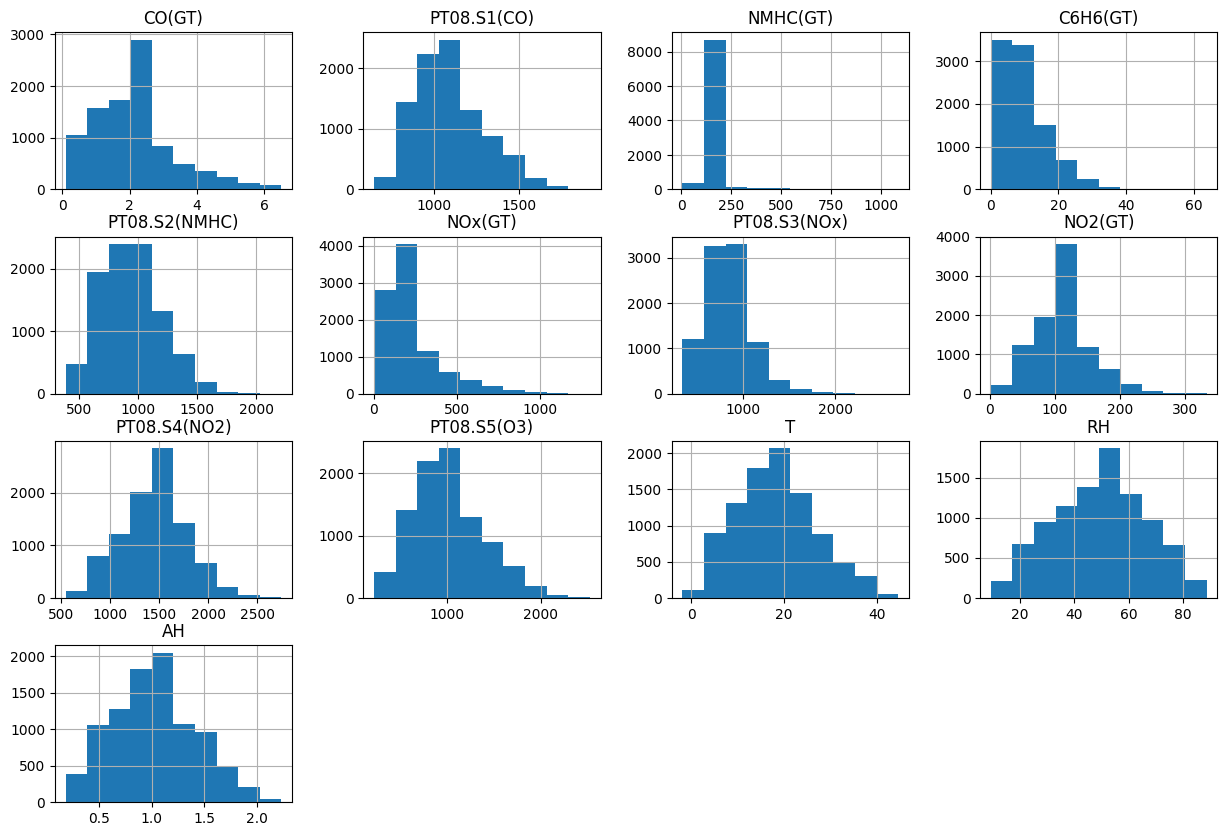

In [ ]:
df.hist(figsize=(15,10))
plt.show()

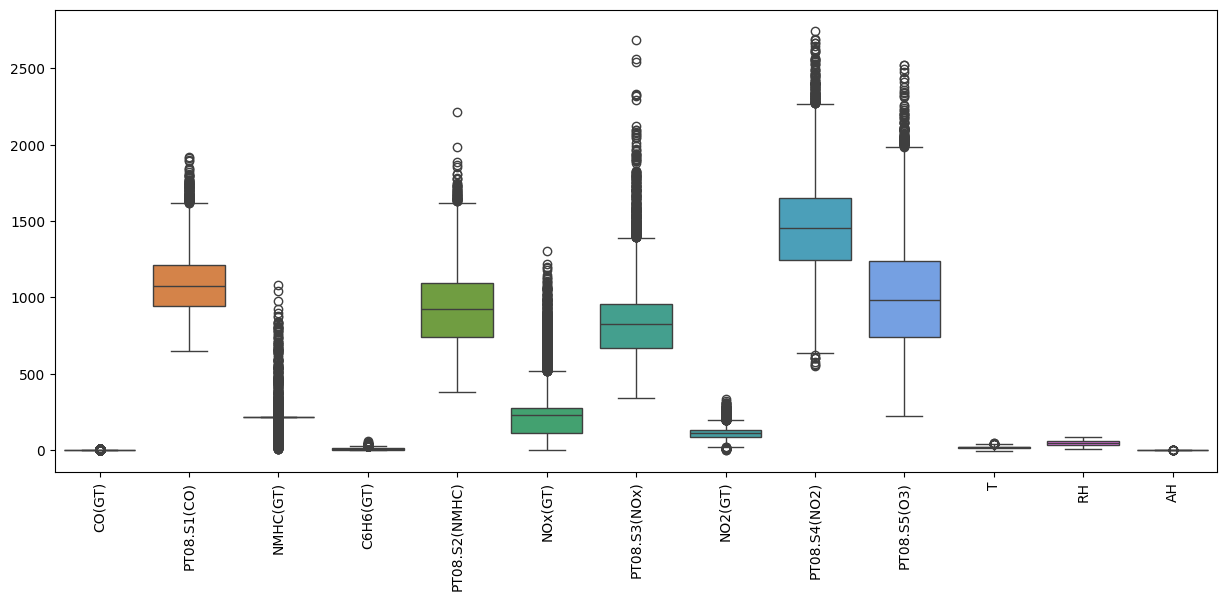

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

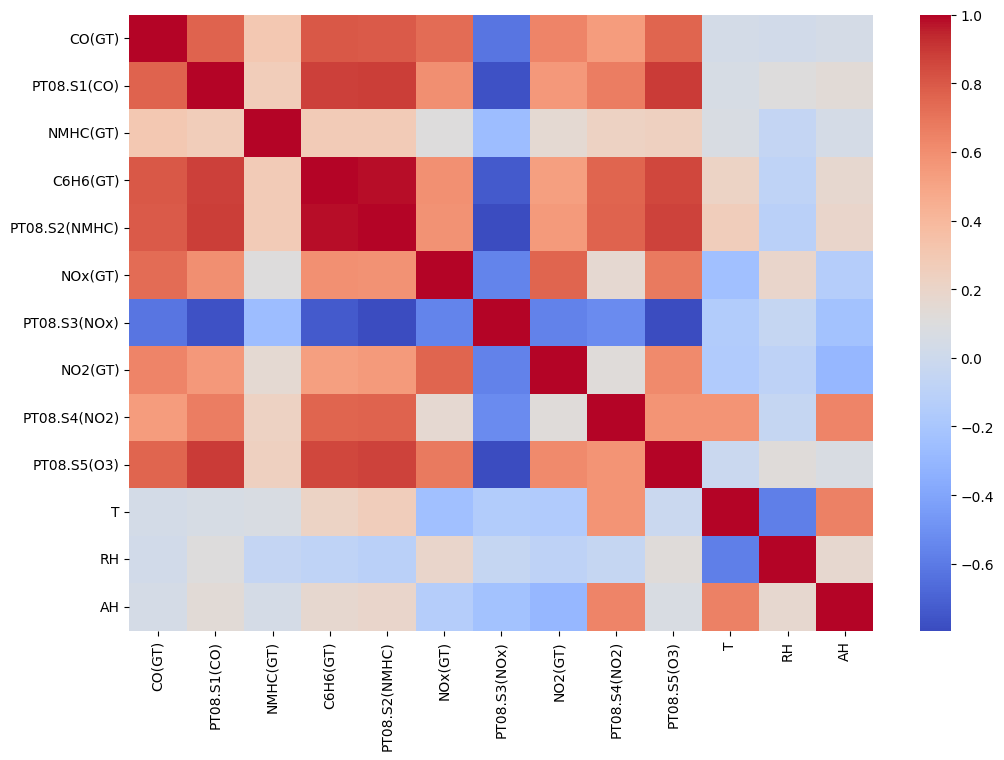

In [ ]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [ ]:
# Removendo variável problemática
X = df.drop(columns=["CO(GT)", "NMHC(GT)"], errors='ignore')
y = df["CO(GT)"]

print(list(X.columns))

['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(C=10, epsilon=0.1))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=["Modelo", "MAE", "MSE", "RMSE", "R2"])
results_df

,Modelo,MAE,MSE,RMSE,R2
0,SVR,0.295598,0.224247,0.473547,0.839116
1,KNN,0.316103,0.219617,0.468633,0.842438
2,RandomForest,0.299180,0.206764,0.454713,0.851660
3,GradientBoosting,0.339708,0.238628,0.488496,0.828799


In [ ]:
best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0]["Modelo"]
best_model = trained_models[best_model_name]

print("Melhor modelo:", best_model_name)

Melhor modelo: RandomForest


## Justificativa do Modelo Escolhido

Após o treinamento e avaliação de quatro algoritmos de regressão no conjunto de teste (20% dos dados), os resultados obtidos foram:

| Modelo            | MAE    | MSE    | RMSE   | R²     |
|-------------------|--------|--------|--------|--------|
| SVR               | 0.2956 | 0.2242 | 0.4735 | 0.8391 |
| KNN               | 0.3161 | 0.2196 | 0.4686 | 0.8424 |
| **RandomForest**  | **0.2992** | **0.2068** | **0.4547** | **0.8517** |
| GradientBoosting  | 0.3397 | 0.2386 | 0.4885 | 0.8288 |

O modelo escolhido foi o **Random Forest Regressor**, por apresentar:

- **Maior R² (0.8517):** explica aproximadamente 85% da variância da concentração de CO(GT), superando todos os demais modelos avaliados.
- **Menor RMSE (0.4547):** indica o menor erro médio em termos da escala original da variável alvo, o que é especialmente relevante para um problema de regressão onde a magnitude do erro importa.
- **Menor MSE (0.2068):** confirma a consistência do modelo em minimizar erros quadráticos.

Em relação aos demais modelos:
- O **SVR** e o **KNN** apresentaram desempenho similar entre si, mas ficaram abaixo do RandomForest em todas as métricas relevantes, mesmo após normalização com .
- O **GradientBoosting** obteve o pior desempenho geral, com maior MAE (0.3397) e menor R² (0.8288), possivelmente por necessitar de ajuste mais fino de hiperparâmetros (learning_rate, n_estimators).

O Random Forest, por sua natureza de ensemble (combinação de múltiplas árvores de decisão), tende a ser mais robusto a outliers residuais e a relações não-lineares entre as variáveis preditoras e o alvo, características presentes neste dataset de qualidade do ar. O treinamento final foi realizado com o conjunto completo de dados para maximizar a capacidade preditiva do modelo exportado.

In [ ]:
best_model.fit(X, y)

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)

In [ ]:
import os
import pickle

# Treinar modelo final com todos os dados
best_model.fit(X, y)

# Criar pasta models
os.makedirs("models", exist_ok=True)

# Salvar modelo na pasta correta
with open("models/model_air_quality.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Modelo exportado com sucesso!")

Modelo exportado com sucesso!


In [ ]:
print(list(X.columns))

['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
